In [25]:
import sys, os, json, warnings
import matplotlib.patches as mpatches
sys.path.insert(0, os.path.abspath("../.."))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.filterwarnings("ignore")

matplotlib.rcParams.update({"font.size": 22})
sns.set(font_scale=2.4)
colormap = sns.color_palette("Blues")

LOGS_ROOT = os.path.abspath("../../.logs")
SIZES = ["very_small", "small", "medium"]

In [26]:
def clean_name(full_id):
    name = full_id.split("/")[-1]
    for suffix in ["-Instruct", "-instruct"]:
        name = name.replace(suffix, "")
    return name

def resource_value(res):
    return sum(res["_value"].values())

def load_games(log_dir):
    records = []
    for root, dirs, files in os.walk(log_dir):
        if "game_state.json" not in files:
            continue
        path = os.path.join(root, "game_state.json")
        try:
            with open(path) as f:
                data = json.load(f)
            last = data["game_state"][-1]
            if last.get("current_iteration") != "END":
                continue
            players = data["players"]
            records.append({
                "game_class": data["class"],
                "model_1": players[0].get("model_id", players[0].get("model")),
                "model_2": players[1].get("model_id", players[1].get("model")),
                "summary": last["summary"],
            })
        except Exception:
            pass
    return records

def make_rename_dict(records):
    models = set()
    for r in records:
        models.add(r["model_1"])
        models.add(r["model_2"])
    return {m: clean_name(m) for m in sorted(models)}

def replace_names(df, rename_dict):
    df = df.copy()
    df["model_1"] = df["model_1"].replace(rename_dict)
    df["model_2"] = df["model_2"].replace(rename_dict)
    return df

def trading_aggregation(df):
    df = df.copy()
    df["models"] = df["model_1"] + "@" + df["model_2"]
    df["win_1"] = df["resource_delta_1"] > df["resource_delta_2"]
    df["win_2"] = df["resource_delta_1"] < df["resource_delta_2"]
    agg = df.groupby(["game_name", "models"])[
        ["win_1", "win_2", "resource_delta_1", "resource_delta_2"]
    ].mean().reset_index()
    agg[["model_1", "model_2"]] = agg["models"].str.split("@", n=1, expand=True)
    total = agg["win_1"] + agg["win_2"]
    agg["win_1"] = agg["win_1"] / total
    agg["win_2"] = agg["win_2"] / total
    return agg

In [27]:
def plot_completion(size):
    size_label = size.replace("_", " ").title()
    games = {
        "Trading": "trading_section_one",
        "Ultimatum": "ultimatum_section_one",
        "Buyer–Seller": "buysell_section_one",
    }
    rows = []
    for game_name, game_dir in games.items():
        for condition in ["no_retries", "retry3"]:
            log_dir = os.path.join(LOGS_ROOT, f"section_one/{game_dir}/{condition}/{size}")
            for root, dirs, files in os.walk(log_dir):
                if "game_state.json" not in files:
                    continue
                try:
                    with open(os.path.join(root, "game_state.json")) as fh:
                        data = json.load(fh)
                    completed = int(data["game_state"][-1].get("current_iteration") == "END")
                    players = data["players"]
                    m1 = clean_name(players[0].get("model_id", players[0].get("model", "?")))
                    m2 = clean_name(players[1].get("model_id", players[1].get("model", "?")))
                    for m in [m1, m2]:
                        rows.append({"game": game_name, "condition": condition,
                                     "model": m, "completed": completed})
                except Exception:
                    pass
    df = pd.DataFrame(rows)
    if df.empty:
        print(f"No data for {size_label}")
        return
    models = sorted(df["model"].unique())
    palette = sns.color_palette("colorblind", n_colors=2)
    fig, axs = plt.subplots(figsize=(22, 7), ncols=3)
    for i, (ax, game_name) in enumerate(zip(axs, games.keys())):
        sub = df[df["game"] == game_name]
        sns.barplot(sub, x="model", y="completed", hue="condition",
                    order=models, hue_order=["no_retries", "retry3"],
                    palette=palette, ax=ax, errorbar="se", capsize=0.1,
                    legend=(i == 2))
        ax.set_ylim(0, 1.15)
        ax.set_title(game_name)
        ax.set_ylabel("Completion Rate" if i == 0 else None)
        ax.set_xlabel(None)
        ax.tick_params(axis="x", rotation=90)
        if i == 2:
            ax.legend(title="Condition", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.suptitle(f"Completion Rate by Model — {size_label}", fontsize=24)
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.32, left=0.07)
    plt.show()

def plot_trading(size, condition="no_retries"):
    size_label = size.replace("_", " ").title()
    log_dir = os.path.join(LOGS_ROOT, f"section_one/trading_section_one/{condition}/{size}")
    records = load_games(log_dir)
    rename_dict = make_rename_dict(records)
    agents = list(rename_dict.values())

    rows = []
    for r in records:
        s = r["summary"]
        rows.append({
            "game_name": r["game_class"],
            "model_1": r["model_1"],
            "model_2": r["model_2"],
            "resource_delta_1": resource_value(s["final_resources"][0]) - resource_value(s["initial_resources"][0]),
            "resource_delta_2": resource_value(s["final_resources"][1]) - resource_value(s["initial_resources"][1]),
        })
    df = replace_names(pd.DataFrame(rows), rename_dict)
    agg = trading_aggregation(df)

    fig, axs = plt.subplots(figsize=(17.6, 8), ncols=2)

    local = agg.pivot(index="model_2", columns="model_1", values="win_2")
    local = local.reindex(agents, axis=1).reindex(agents)
    mask = np.eye(local.values.shape[0], dtype=bool)
    p1 = sns.heatmap(local, annot=True, mask=mask, fmt=".2f", cmap=colormap, ax=axs[0])
    p1.set_ylabel("Player 2", fontdict=dict(weight="bold", size=30))
    p1.set_xlabel("Player 1", fontdict=dict(weight="bold", size=30))
    p1.set_title("Win Rate (Player 2)")
    p1.set_xticklabels(agents, rotation=30, ha="right")
    p1.set_yticklabels(agents, rotation=0)

    local = agg.pivot(index="model_2", columns="model_1", values="resource_delta_2")
    local = local.reindex(agents, axis=1).reindex(agents)
    mask = np.eye(local.values.shape[0], dtype=bool)
    p2 = sns.heatmap(local, annot=True, mask=mask, fmt=".2f", cmap=colormap, ax=axs[1])
    p2.set_ylabel("")
    p2.set_xlabel("Player 1", fontdict=dict(weight="bold", size=30))
    p2.set_title("Payoff (Player 2)")
    p2.set_xticklabels(agents, rotation=30, ha="right")
    p2.set_yticklabels([])

    fig.suptitle(f"Trading — {size_label}", fontsize=28, y=1.02)
    fig.tight_layout()
    plt.show()


def plot_ultimatum(size, condition="no_retries"):
    size_label = size.replace("_", " ").title()
    log_dir = os.path.join(LOGS_ROOT, f"section_one/ultimatum_section_one/{condition}/{size}")
    records = load_games(log_dir)
    rename_dict = make_rename_dict(records)
    agents = list(rename_dict.values())

    rows = []
    for r in records:
        s = r["summary"]
        rows.append({
            "game_name": r["game_class"],
            "model_1": r["model_1"],
            "model_2": r["model_2"],
            "resource_delta_1": resource_value(s["final_resources"][0]) - resource_value(s["initial_resources"][0]),
            "resource_delta_2": resource_value(s["final_resources"][1]) - resource_value(s["initial_resources"][1]),
        })
    df = replace_names(pd.DataFrame(rows), rename_dict)
    df["resource_delta_1"] = df["resource_delta_1"] + 100
    df.loc[df["resource_delta_1"] == 100, "resource_delta_1"] = 0
    agg = trading_aggregation(df)

    fig, axs = plt.subplots(figsize=(17.6, 8), ncols=2)

    local = agg.pivot(index="model_1", columns="model_2", values="win_1")
    local = local.reindex(agents, axis=1).reindex(agents)
    mask = np.eye(local.values.shape[0], dtype=bool)
    p1 = sns.heatmap(local, annot=True, mask=mask, fmt=".2f", cmap=colormap, ax=axs[0])
    p1.set_title("Win Rate (Proposer)")
    p1.set_ylabel("Player 1 (Proposer)", fontdict=dict(weight="bold", size=30))
    p1.set_xlabel("Player 2 (Responder)", fontdict=dict(weight="bold", size=30))
    p1.set_xticklabels(agents, rotation=30, ha="right")
    p1.set_yticklabels(agents, rotation=0)

    local = agg.pivot(index="model_1", columns="model_2", values="resource_delta_1")
    local = local.reindex(agents, axis=1).reindex(agents)
    mask = np.eye(local.values.shape[0], dtype=bool)
    p2 = sns.heatmap(local, annot=True, mask=mask, fmt=".1f", cmap=colormap, ax=axs[1])
    p2.set_ylabel("")
    p2.set_xlabel("Player 2 (Responder)", fontdict=dict(weight="bold", size=30))
    p2.set_title("Proposer Payoff")
    p2.set_xticklabels(agents, rotation=30, ha="right")
    p2.set_yticklabels([])

    fig.suptitle(f"Ultimatum — {size_label}", fontsize=28, y=1.02)
    fig.tight_layout()
    plt.show()


def plot_buysell(size, condition="no_retries"):
    size_label = size.replace("_", " ").title()
    log_dir = os.path.join(LOGS_ROOT, f"section_one/buysell_section_one/{condition}/{size}")
    records = load_games(log_dir)
    rename_dict = make_rename_dict(records)
    agents = list(rename_dict.values())

    rows = []
    for r in records:
        s = r["summary"]
        outcome = s["player_outcome"]
        vals = s.get("player_valuation", [None, None])
        val_1 = vals[0]["_value"]["X"] if vals and vals[0] else None
        val_2 = vals[1]["_value"]["X"] if vals and vals[1] else None
        rows.append({
            "model_1": r["model_1"],
            "model_2": r["model_2"],
            "outcome_1": outcome[0],
            "outcome_2": outcome[1],
            "vals1": val_1,
            "vals2": val_2,
        })
    df = replace_names(pd.DataFrame(rows), rename_dict)
    df["outcome_2"] = pd.to_numeric(df["outcome_2"], errors="coerce")
    df["outcome_1"] = pd.to_numeric(df["outcome_1"], errors="coerce")

    seller_at_40 = df[df["vals1"] == 40].copy()
    palette = dict(zip(agents, sns.color_palette("colorblind", n_colors=len(agents))))

    fig, axs = plt.subplots(1, len(agents), figsize=(5 * len(agents), 6))
    fig.suptitle(f"Buyer's Payoff (willingness to pay − agreed price) — {size_label}", fontsize=24)
    for local_agent, ax in zip(agents, axs):
        others = [a for a in agents if a != local_agent]
        sub = seller_at_40[
            (seller_at_40["model_2"] == local_agent) &
            (seller_at_40["model_1"].isin(others))
        ]
        sns.barplot(
            sub, x="model_1", y="outcome_2", hue="model_1",
            order=others, dodge=False, ax=ax, palette=palette,
            errorbar="se", capsize=0.2,
        )
        if ax.get_legend():
            ax.get_legend().remove()
        ax.set_ylim(0, 25)
        ax.set_xlabel(f"{local_agent}\nBuyer (val 60)")
        ax.set_ylabel(None)
        ax.set_xticklabels([])
    custom_lines = [mpatches.Patch(color=palette[a], label=a) for a in agents]
    fig.legend(
        handles=custom_lines, ncol=len(agents),
        loc="lower center", bbox_to_anchor=(0.5, -0.22),
        title="Sellers (valuation 40)",
    )
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.28)
    plt.show()

# Section One

## Completion Rate

### Very Small

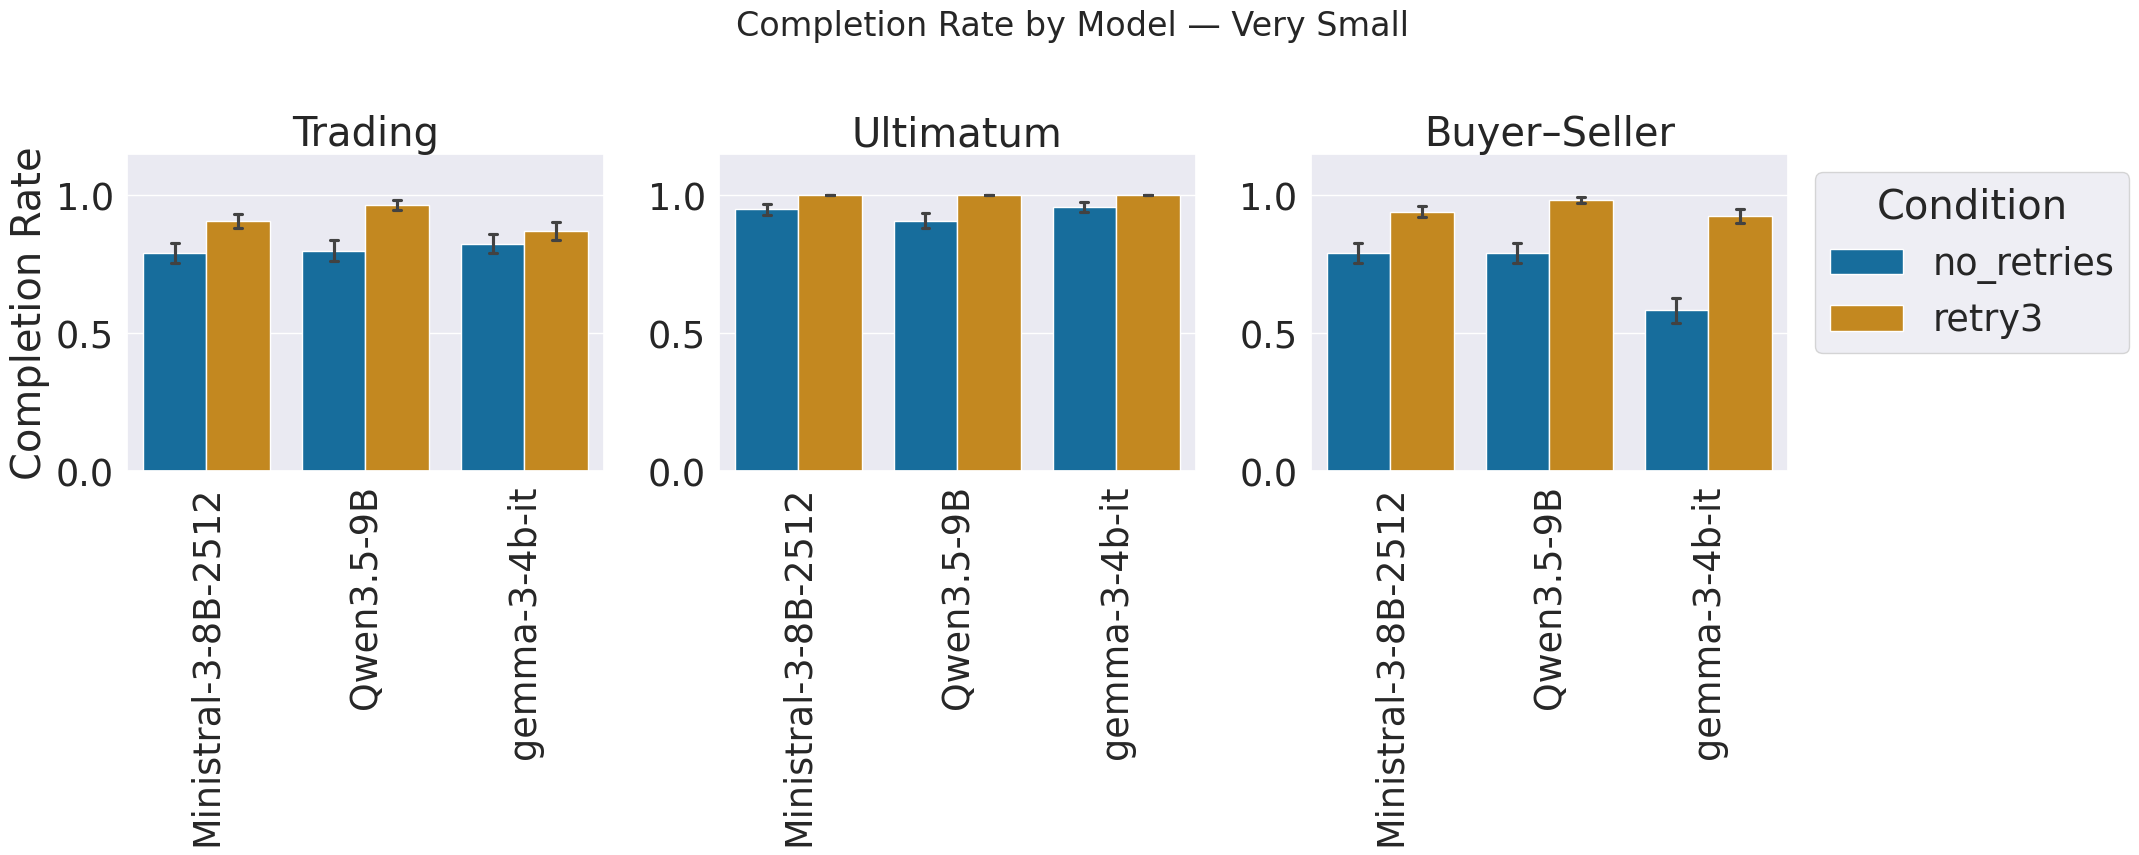

In [28]:
plot_completion("very_small")

### Small

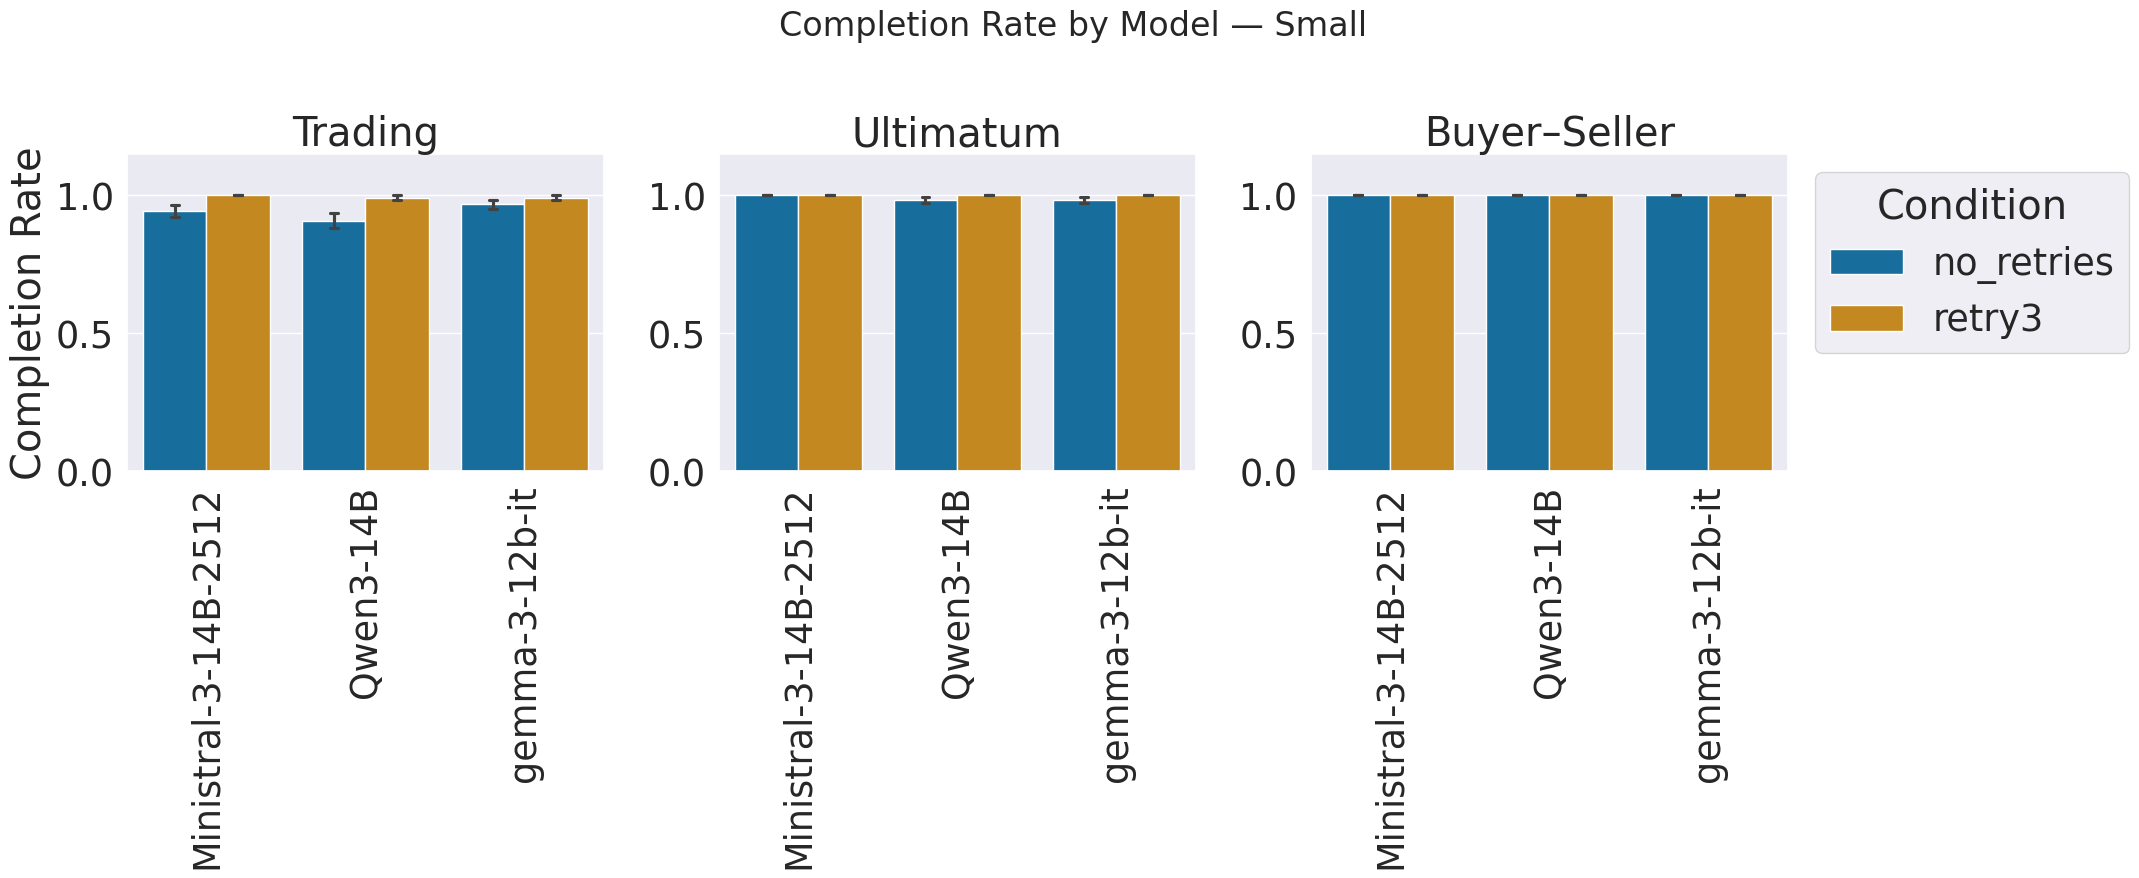

In [29]:
plot_completion("small")

### Medium

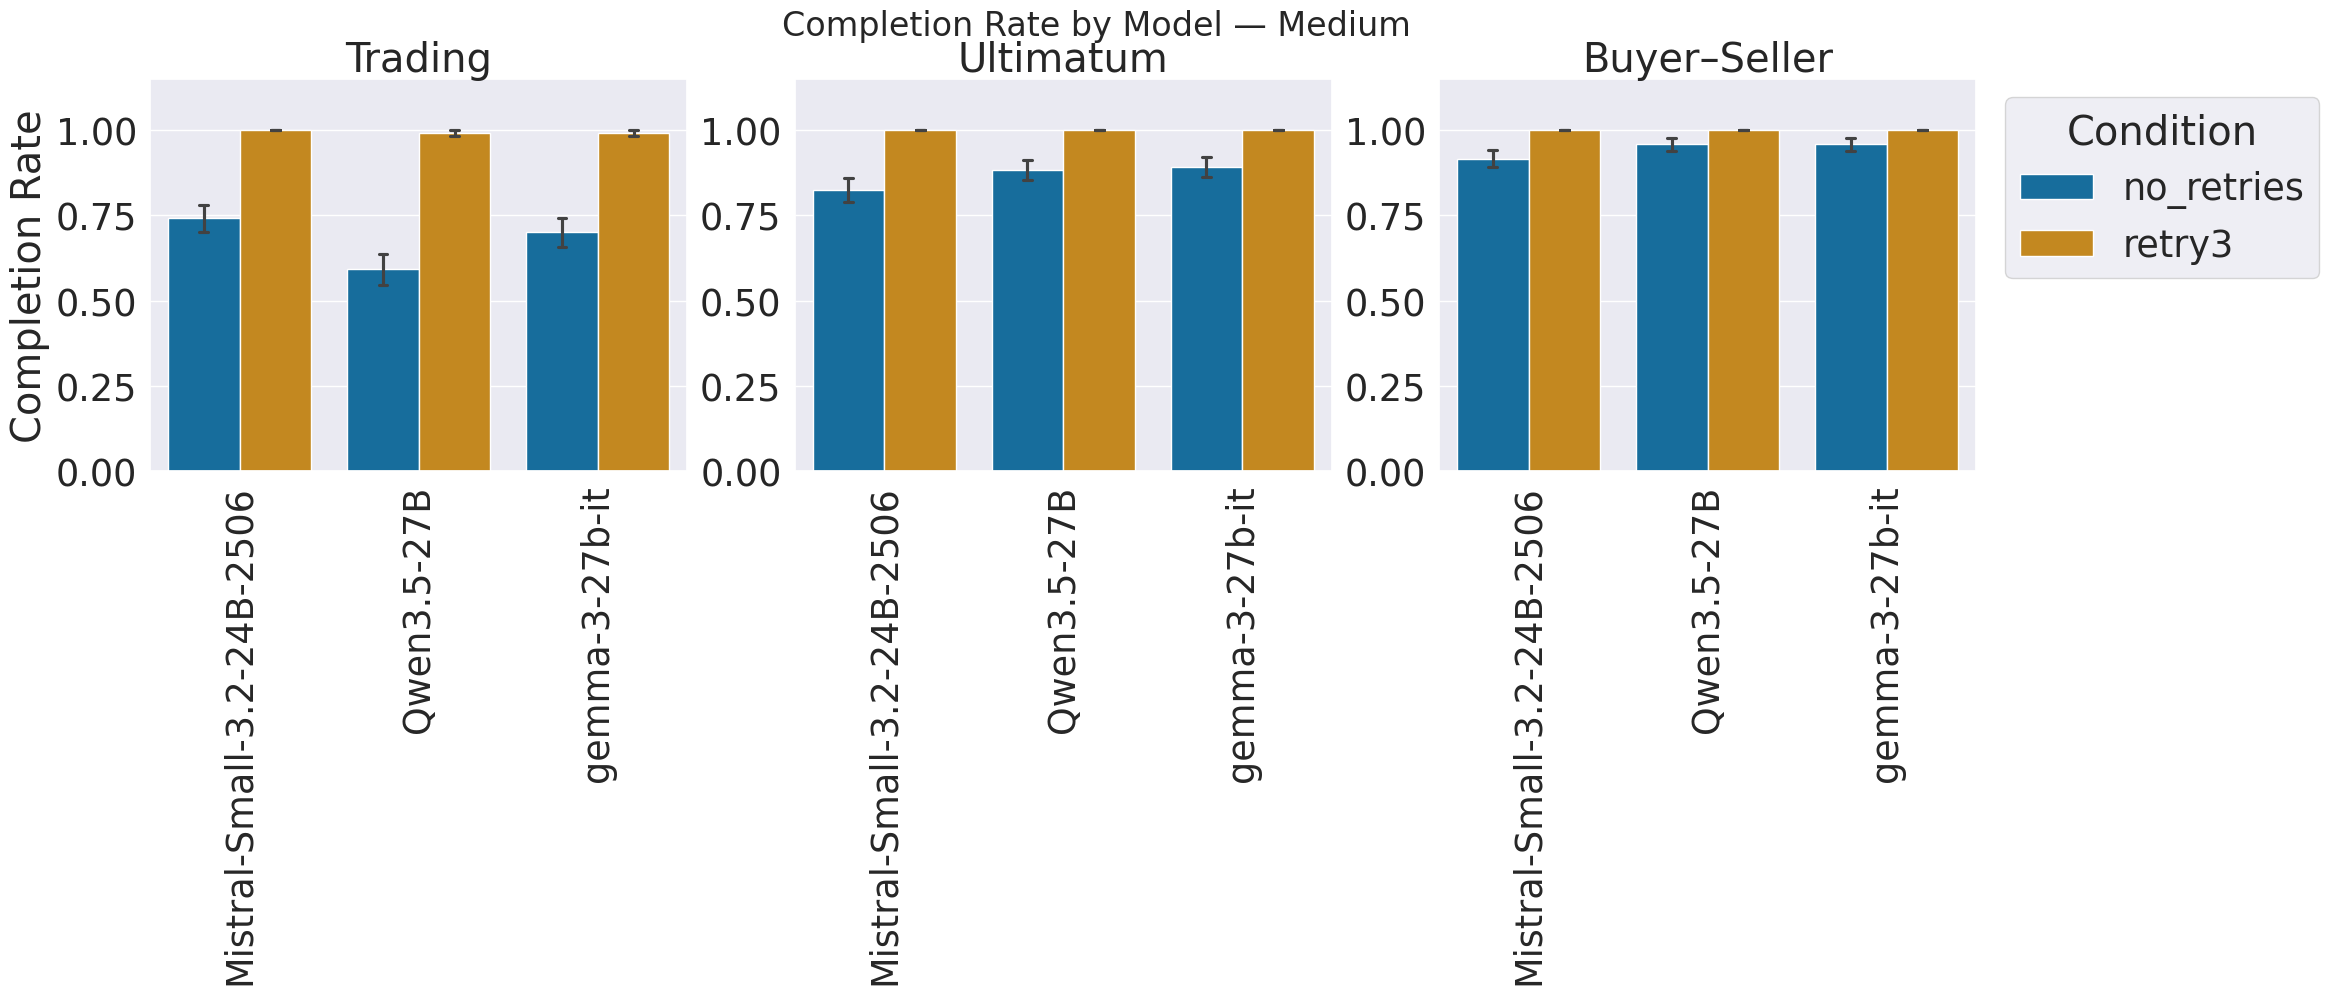

In [30]:
plot_completion("medium")

Analyzing the completion rate plots, we can observe that:

- The retry mechanism (prompting the model to retry its response) works well, achieving completion rates close to 100%.
- For smaller models, the completion rate is notably lower, most notably in the BuySell game and with Gemma models.
- Counterintuitively, completion rates for small models (~12B) are higher than for medium models(~24B).

---
## Retry 3

### Very Small

#### Trading

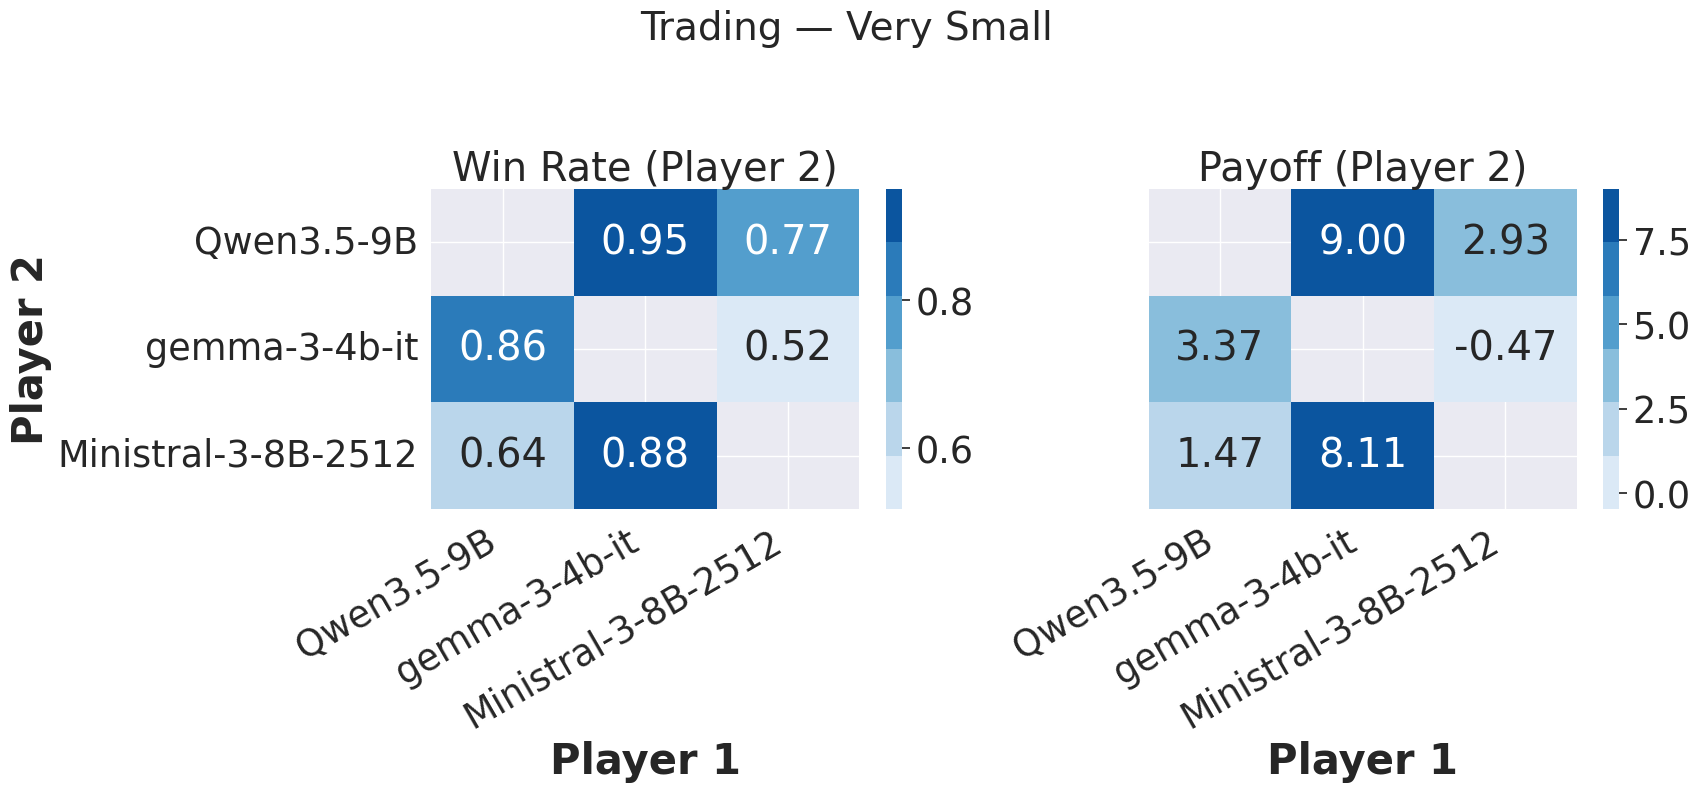

In [31]:
plot_trading("very_small", condition="retry3")

#### Ultimatum

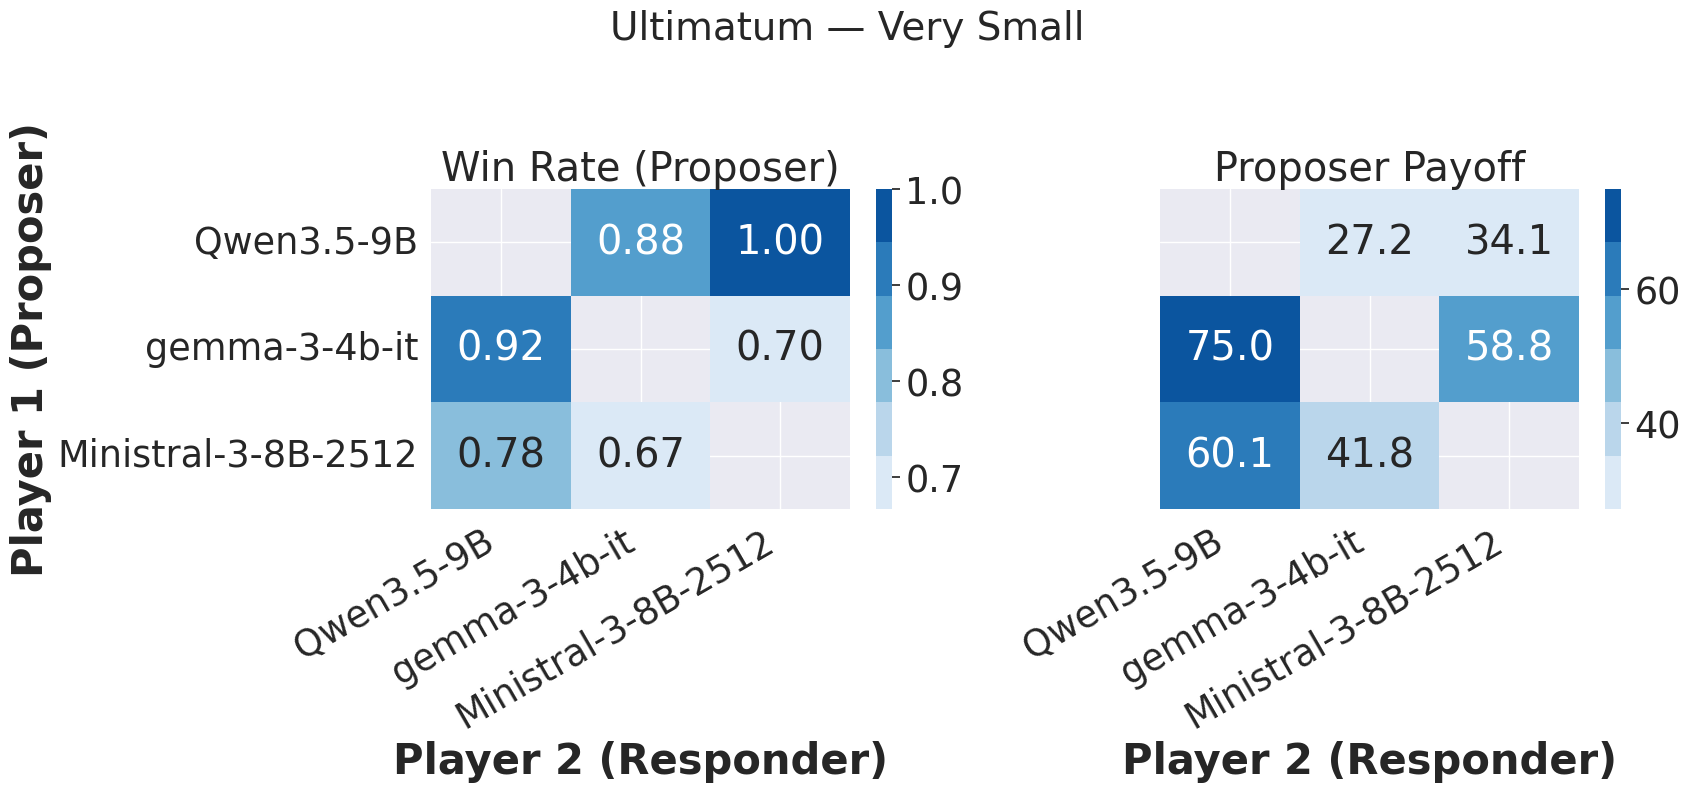

In [32]:
plot_ultimatum("very_small", condition="retry3")

#### Buyer–Seller

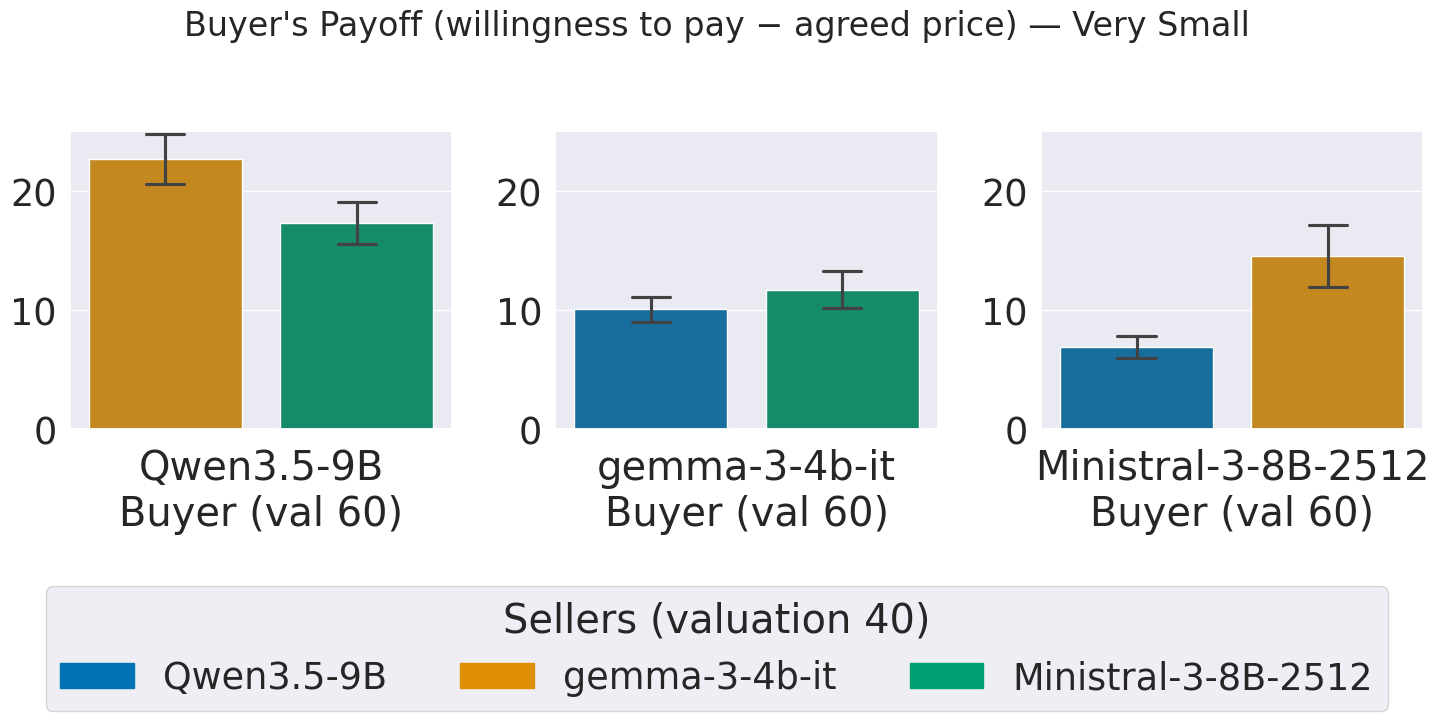

In [33]:
plot_buysell("very_small", condition="retry3")

---
### Small

#### Trading

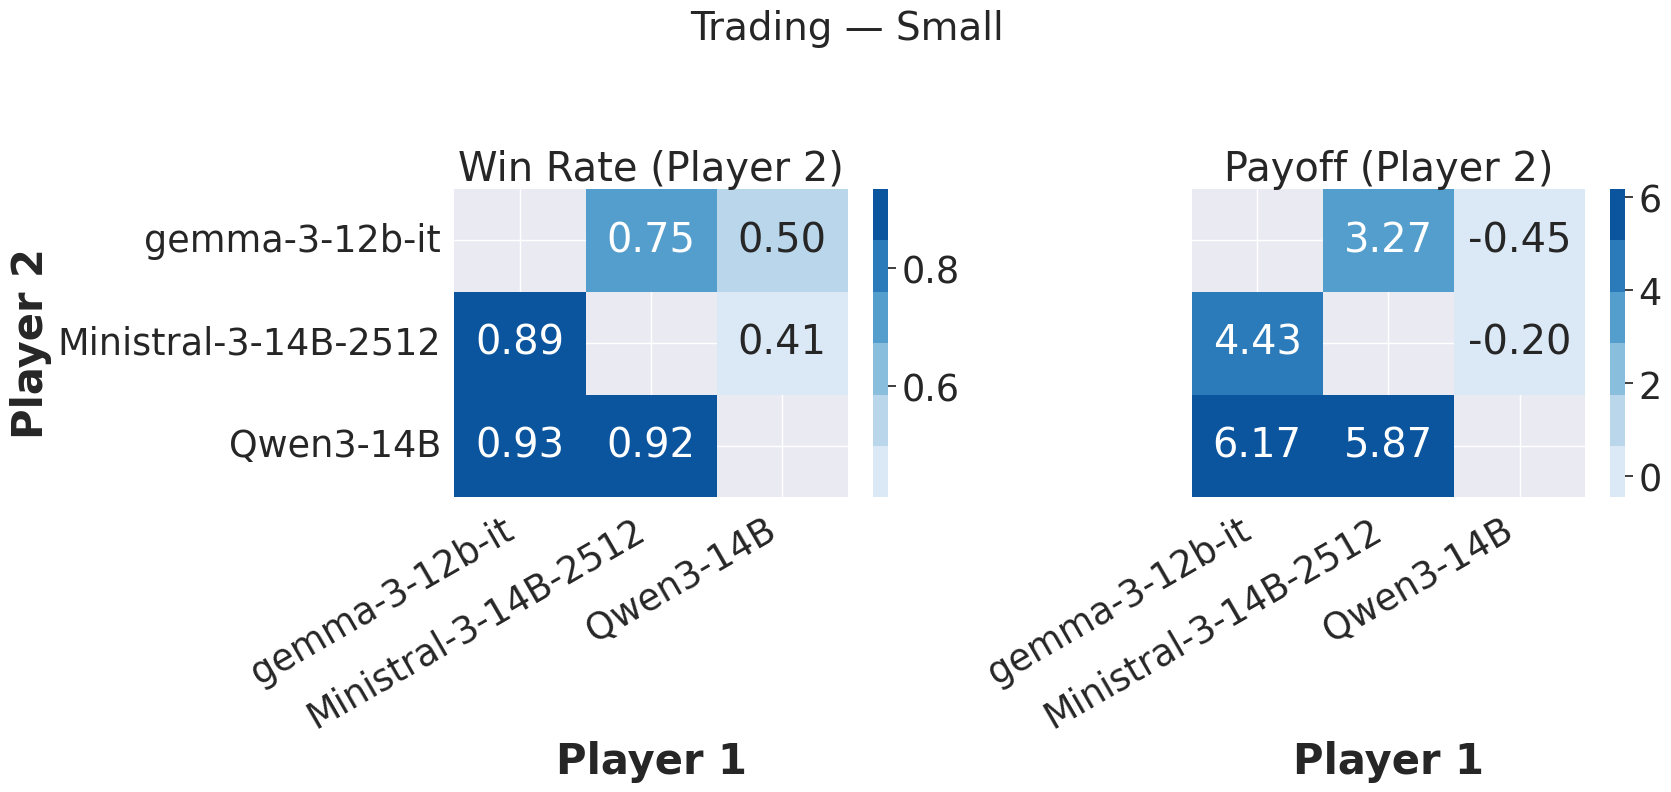

In [34]:
plot_trading("small", condition="retry3")

#### Ultimatum

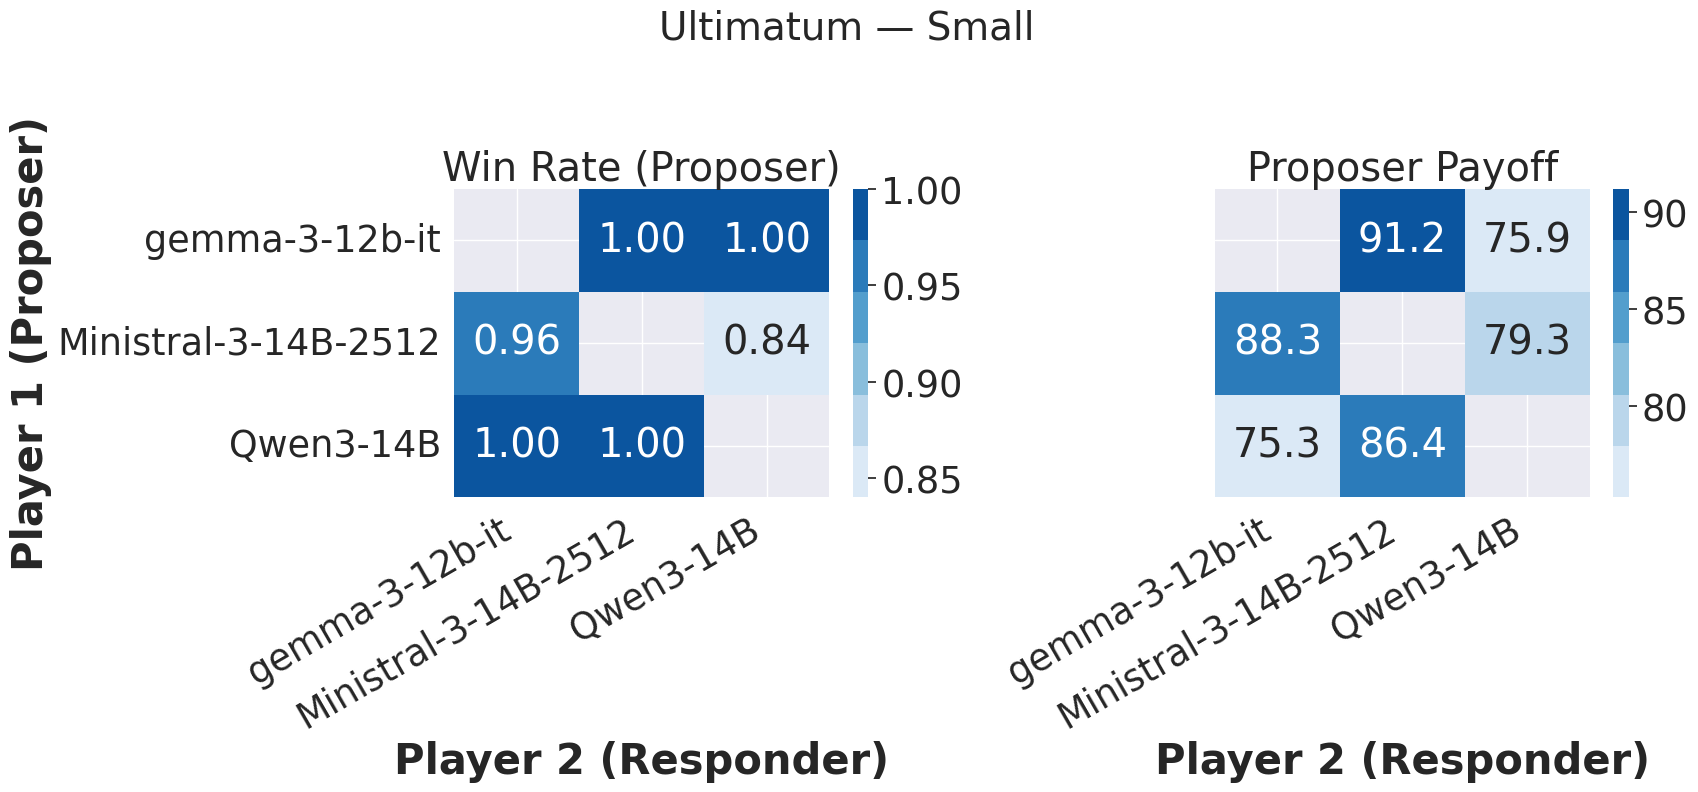

In [35]:
plot_ultimatum("small", condition="retry3")

#### Buyer–Seller

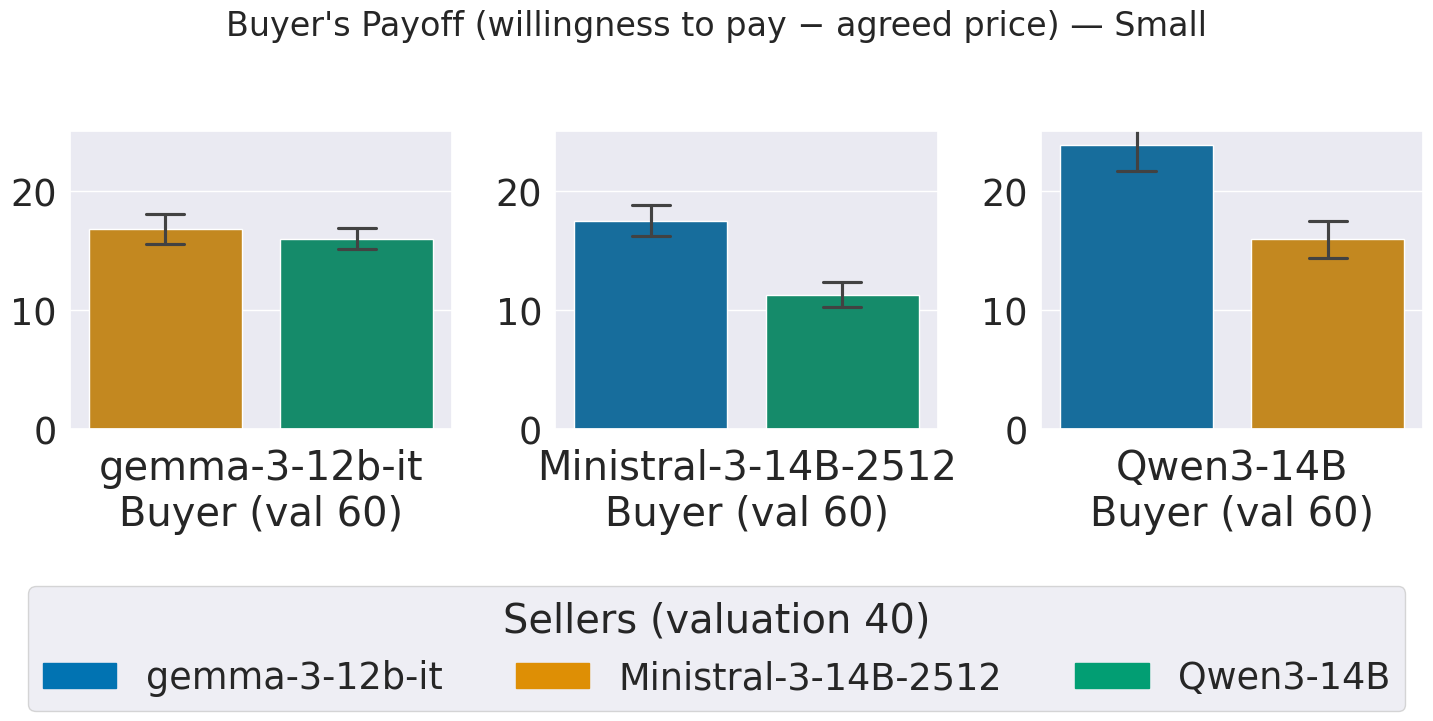

In [36]:
plot_buysell("small", condition="retry3")

Analyzing the completion rate plots, we can observe that:

- The retry mechanism (where the model is prompted to retry its response) works, achieving completion rates close to 100%;
- For very small models, the completion rate is lower (especially without retry), especially for the 

---
### Medium

#### Trading

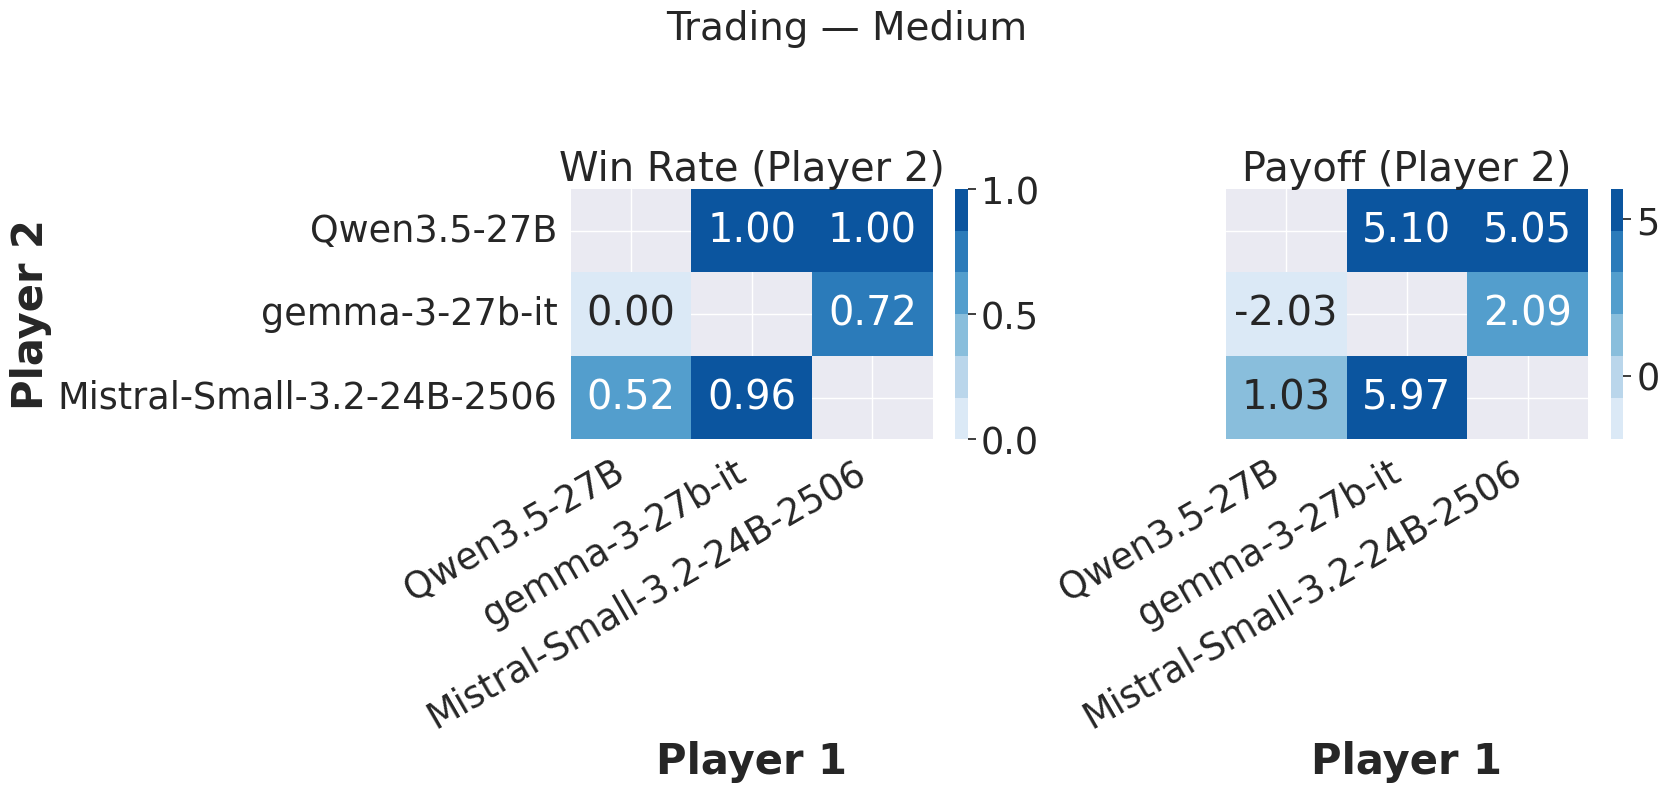

In [37]:
plot_trading("medium", condition="retry3")

#### Ultimatum

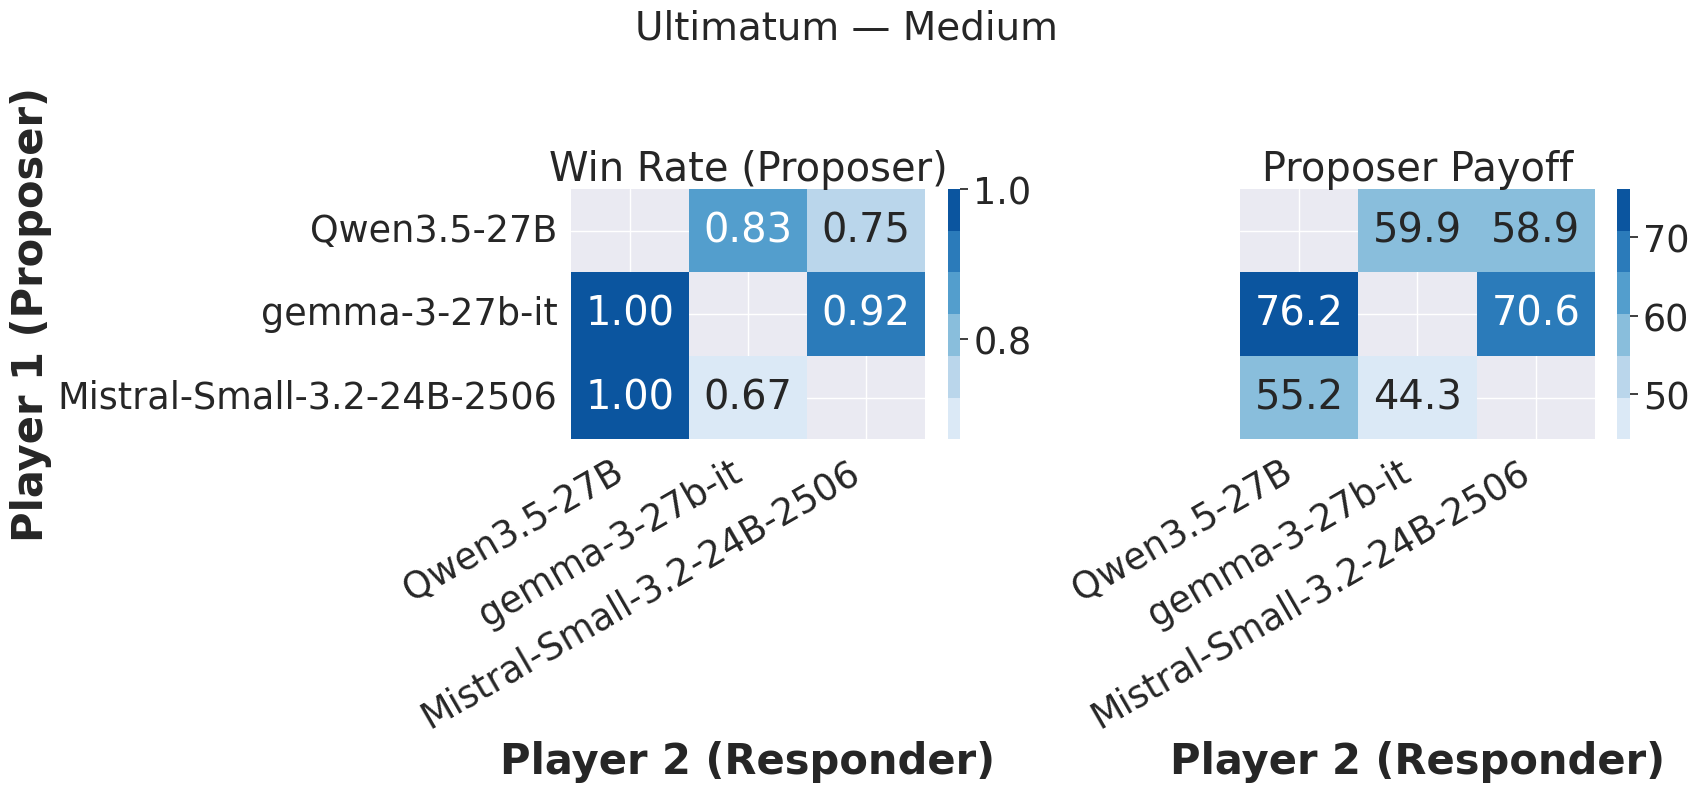

In [38]:
plot_ultimatum("medium", condition="retry3")

#### Buyer–Seller

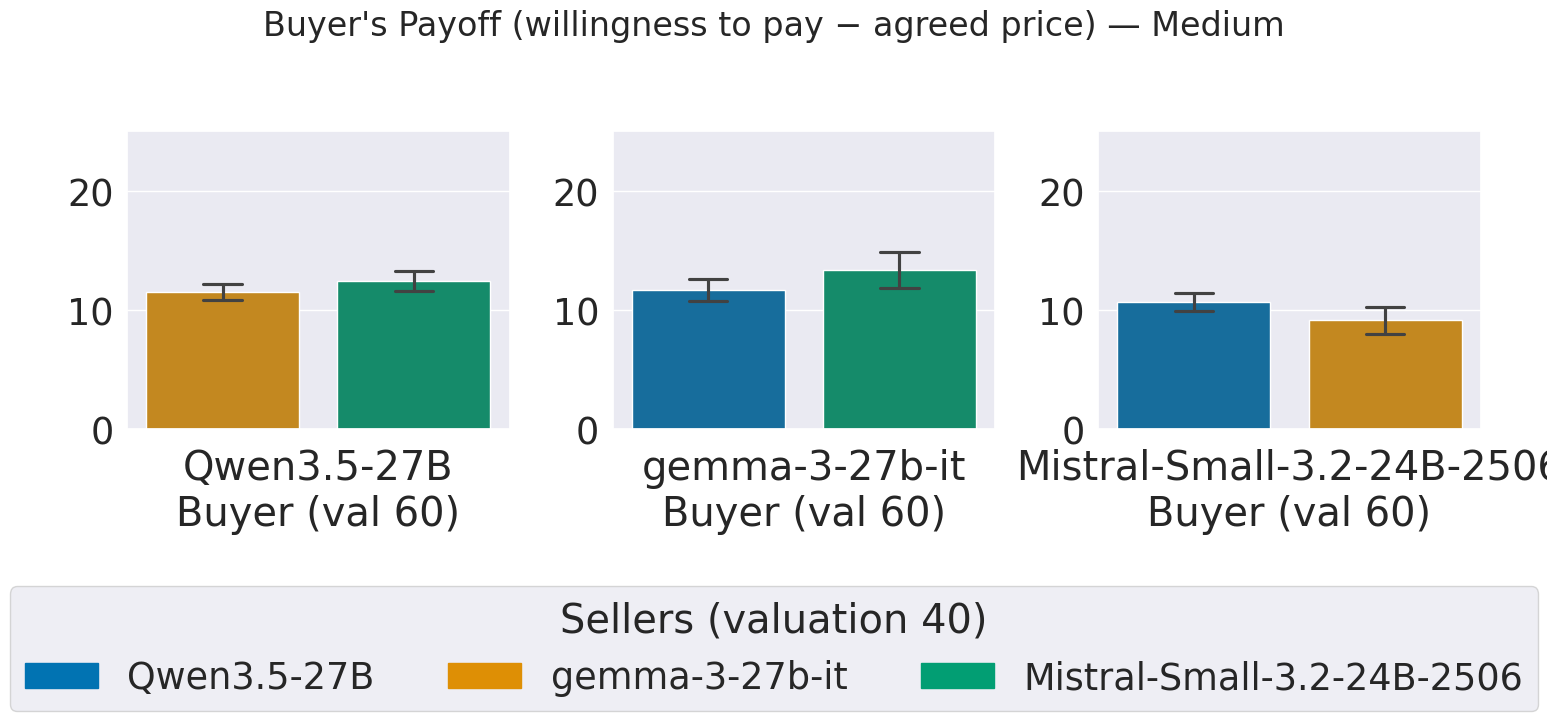

In [39]:
plot_buysell("medium", condition="retry3")

---
## No Retries

### Very Small

#### Trading

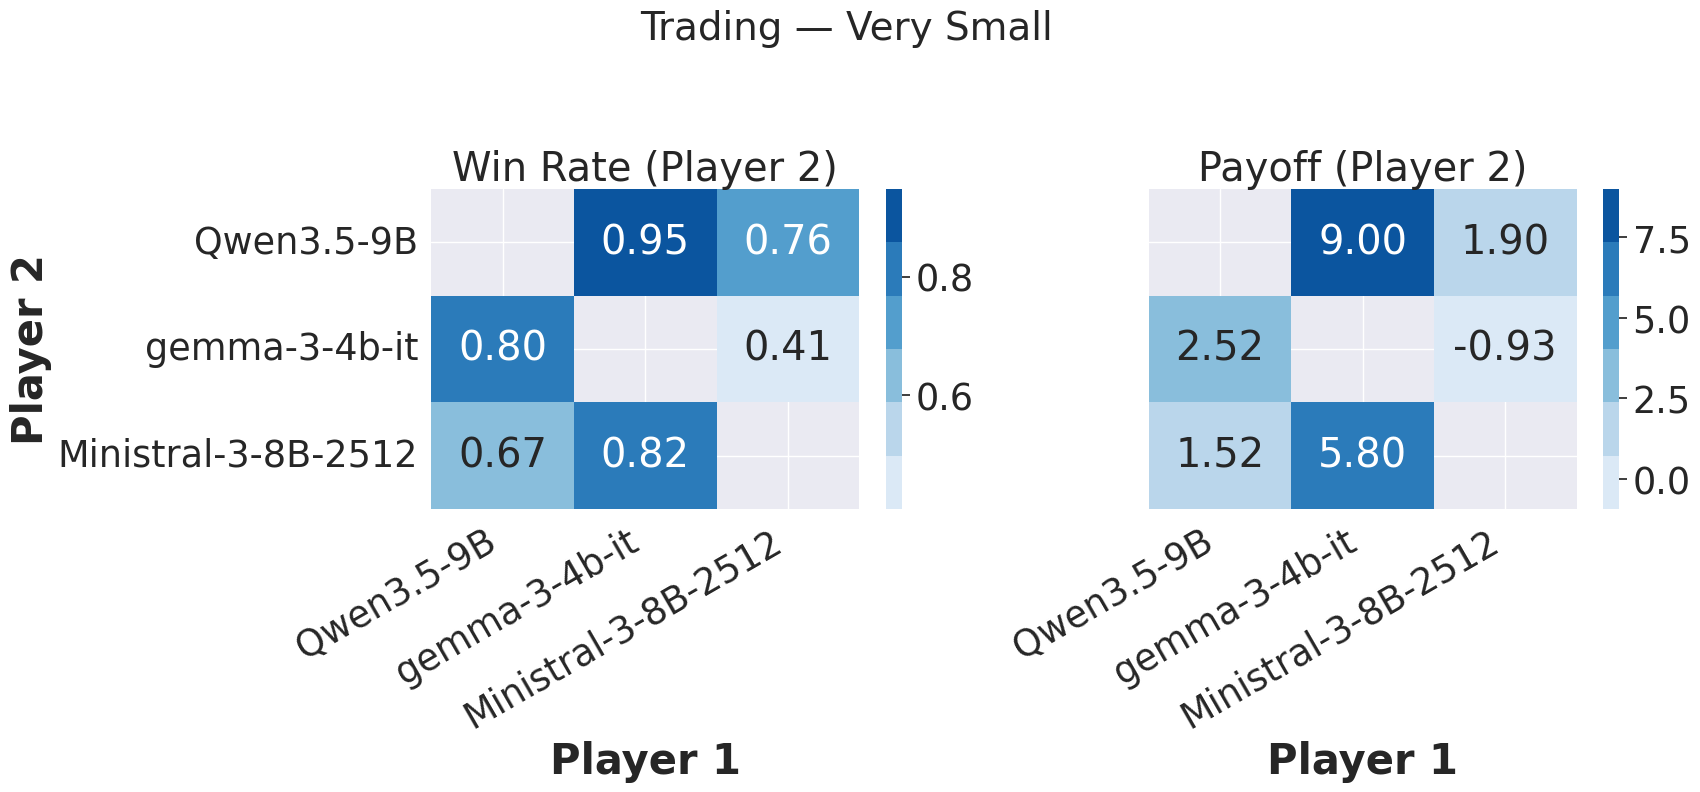

In [40]:
plot_trading("very_small")

#### Ultimatum

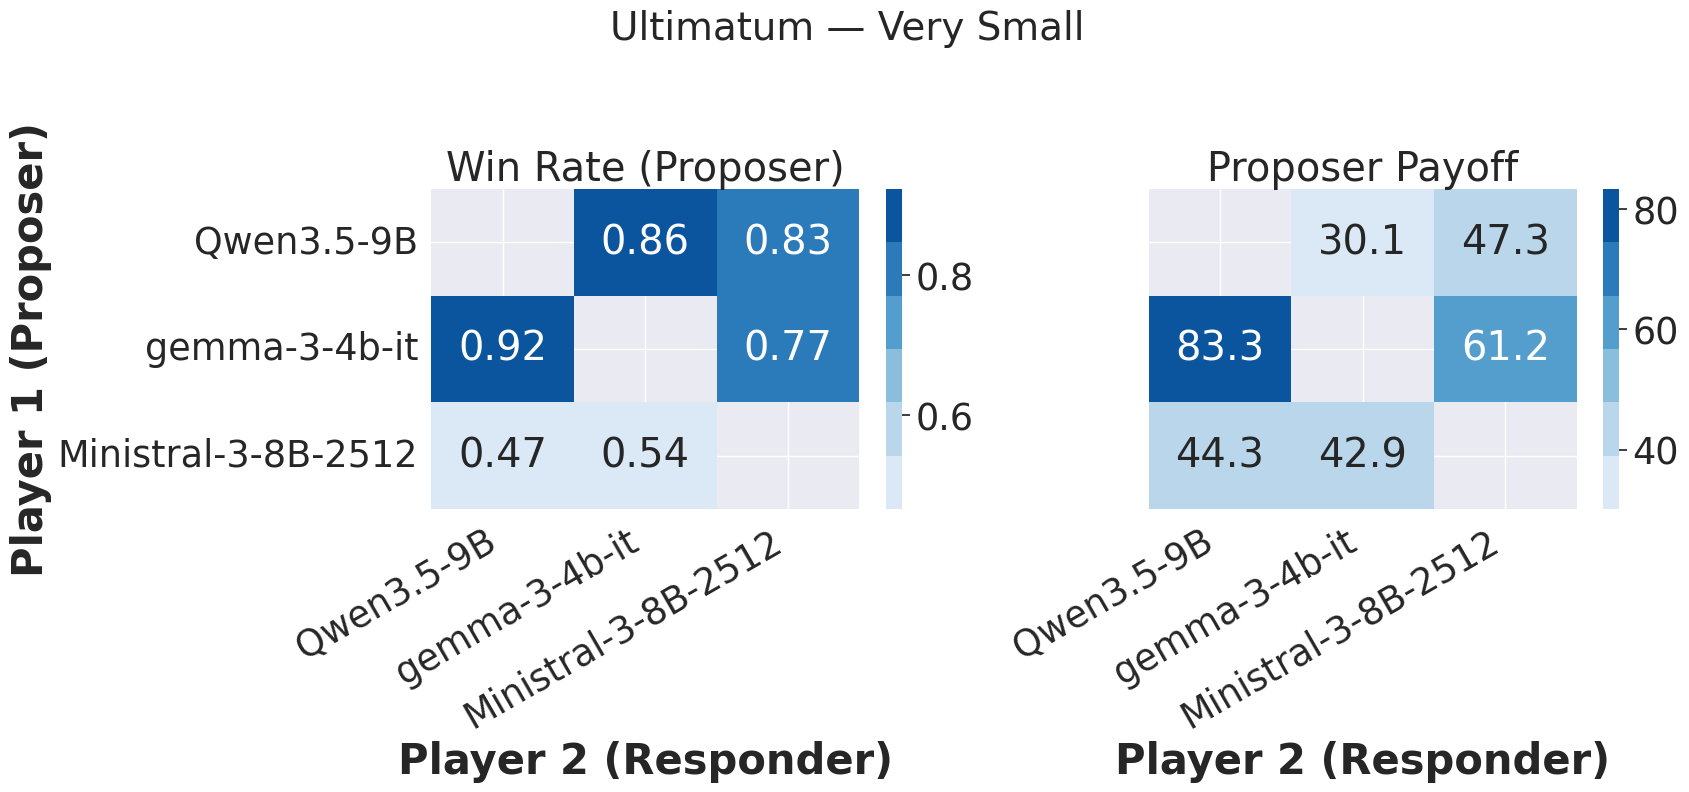

In [41]:
plot_ultimatum("very_small")

#### Buyer–Seller

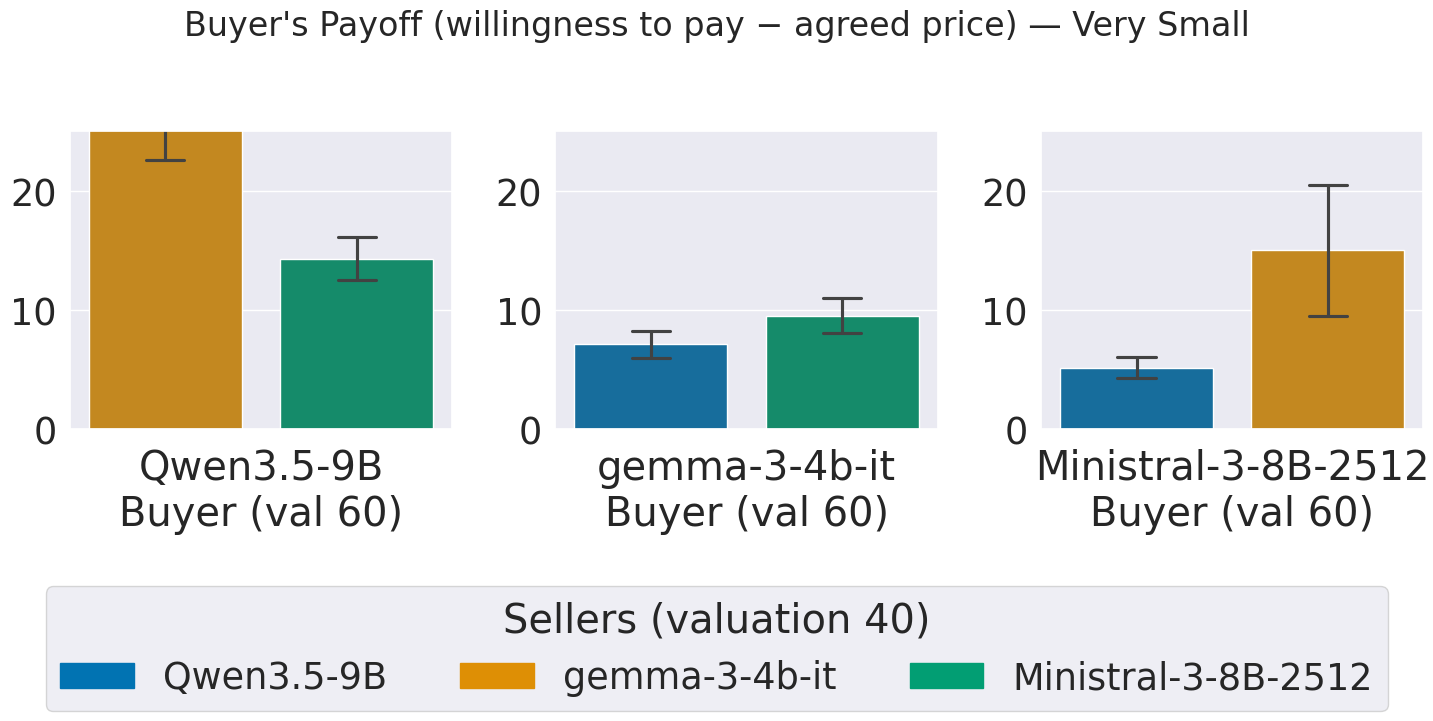

In [42]:
plot_buysell("very_small")

---
### Small

#### Trading

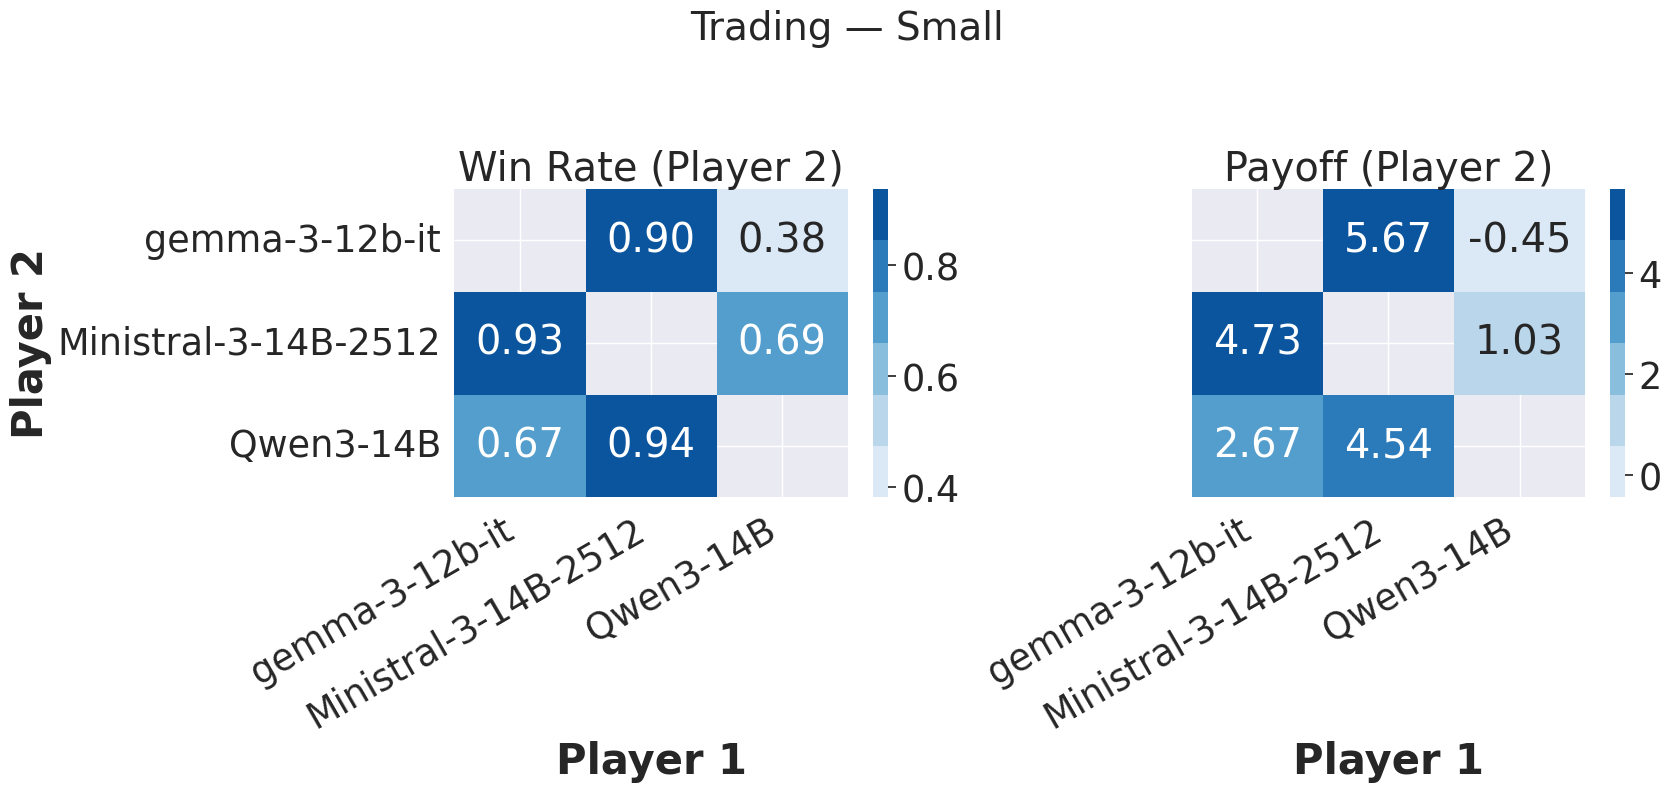

In [43]:
plot_trading("small")

#### Ultimatum

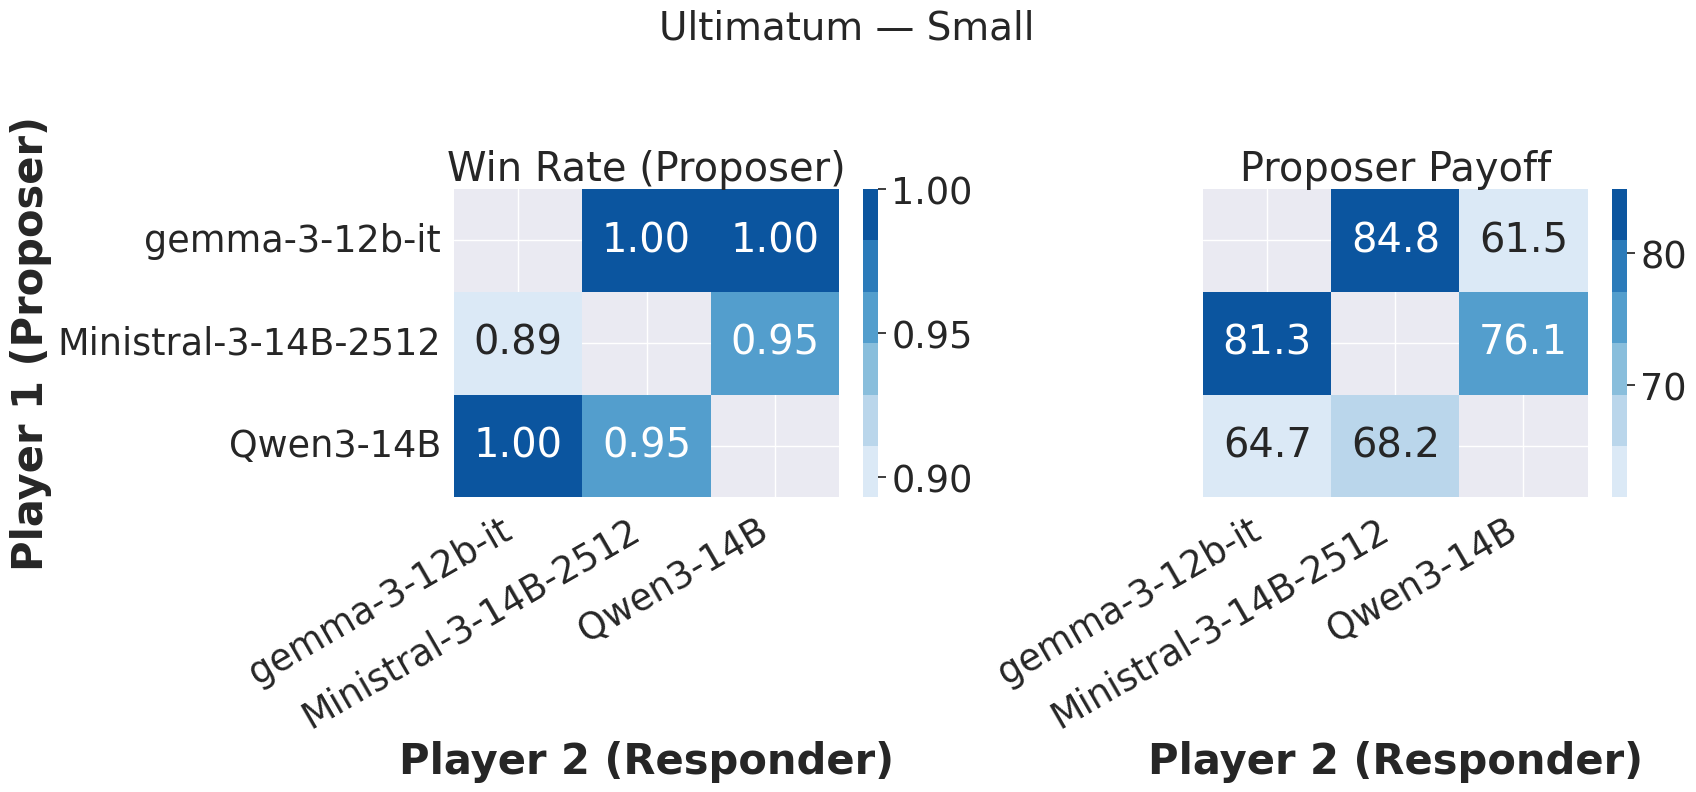

In [44]:
plot_ultimatum("small")

#### Buyer–Seller

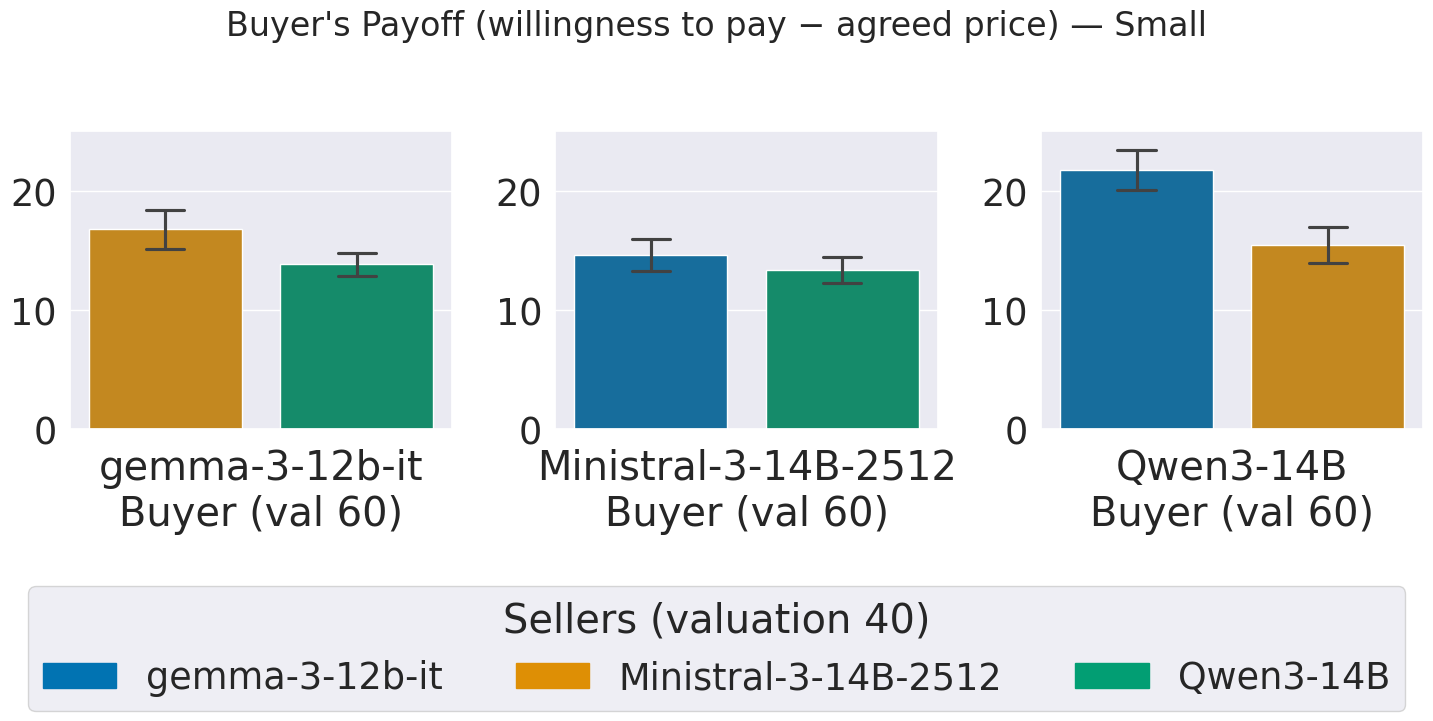

In [45]:
plot_buysell("small")

---
### Medium

#### Trading

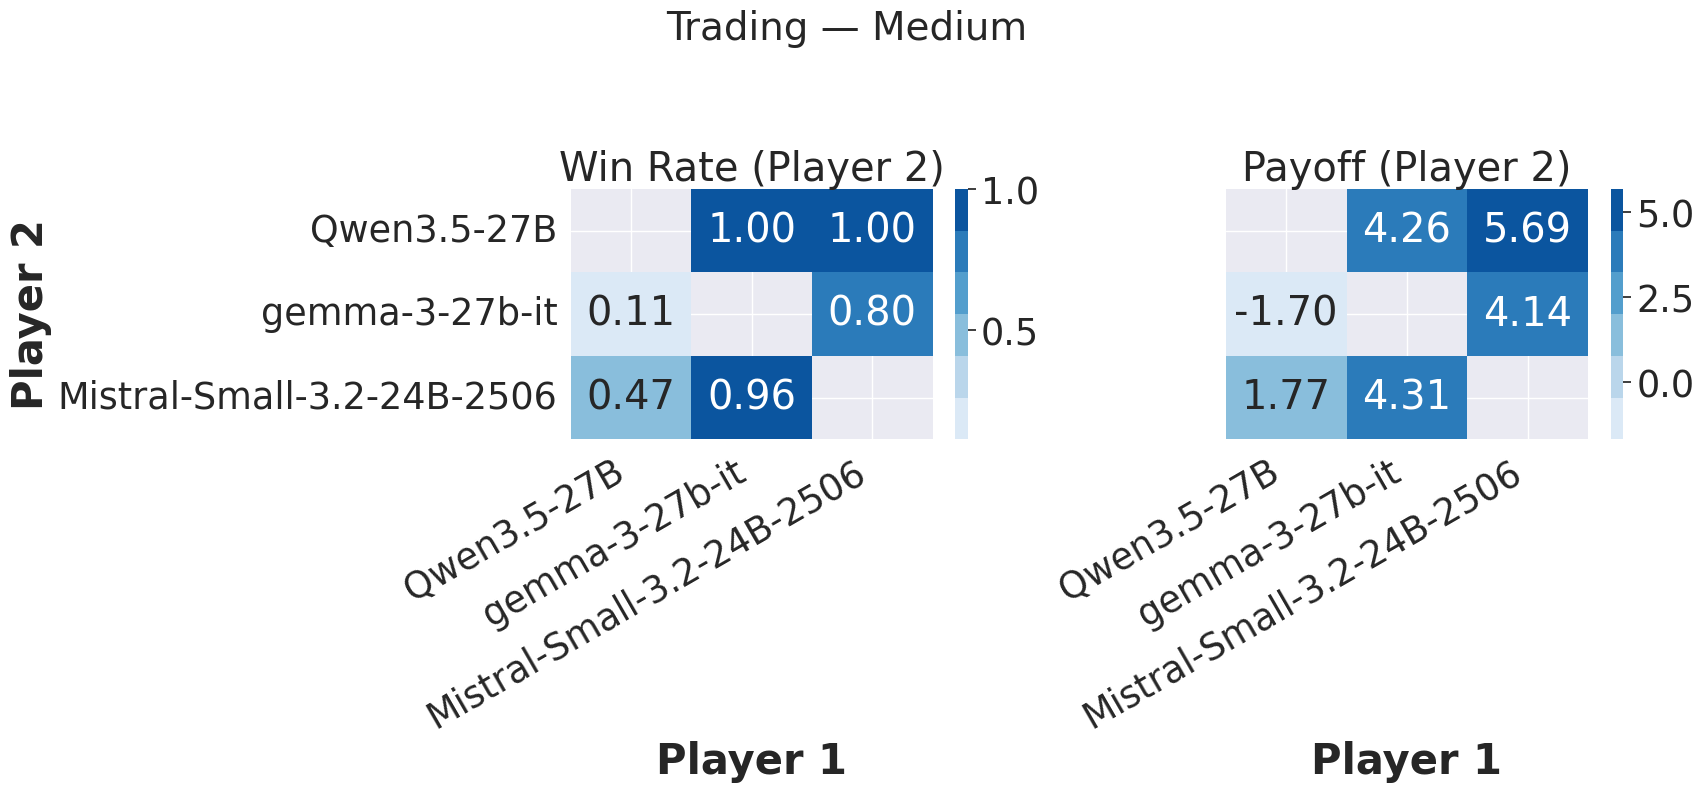

In [46]:
plot_trading("medium")

#### Ultimatum

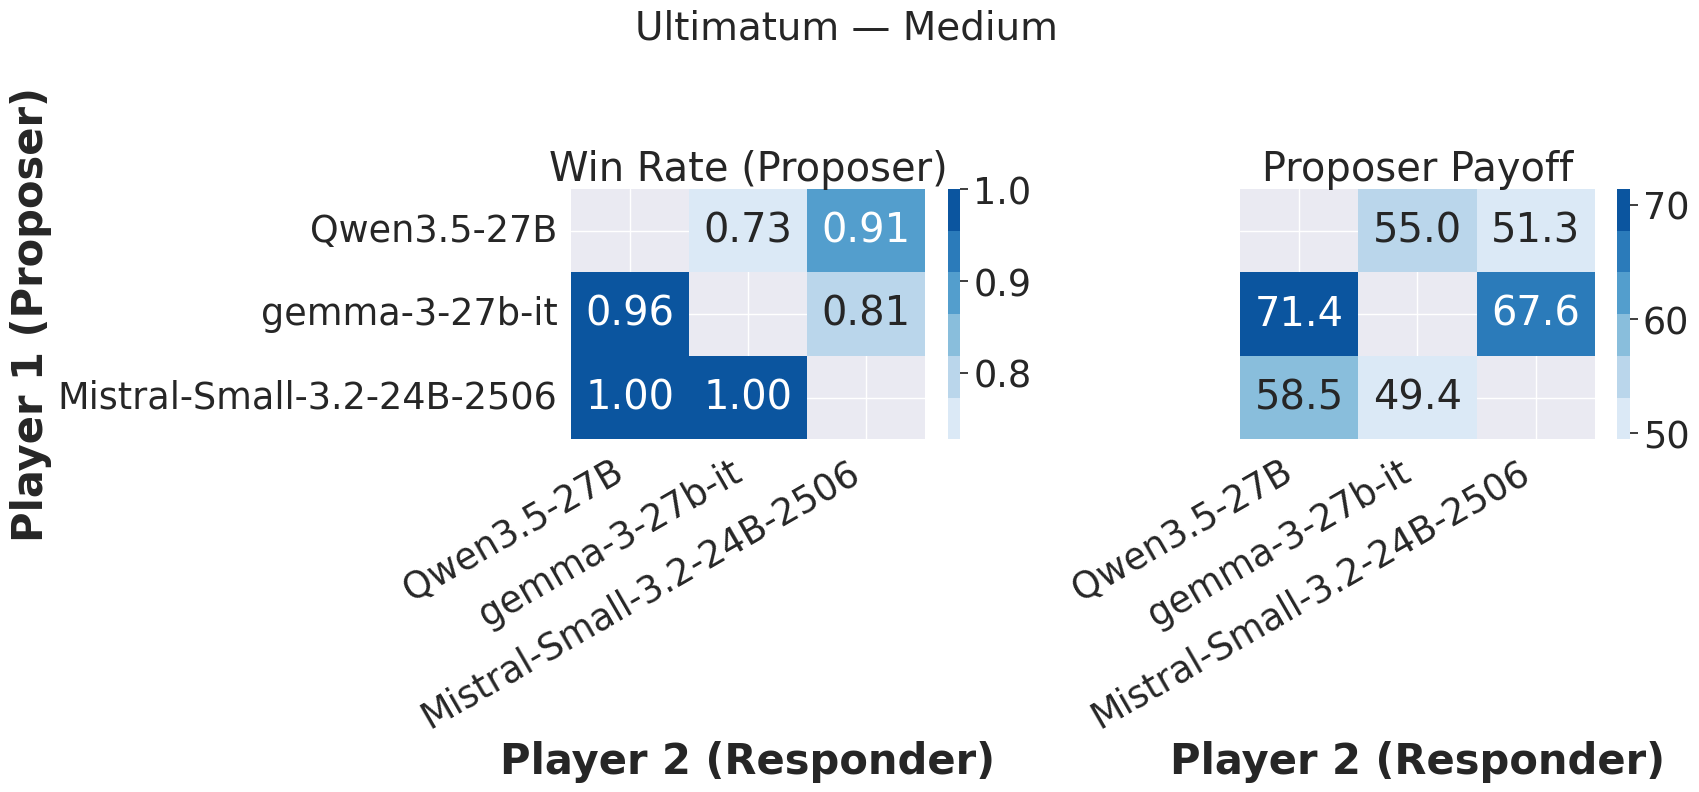

In [47]:
plot_ultimatum("medium")

#### Buyer–Seller

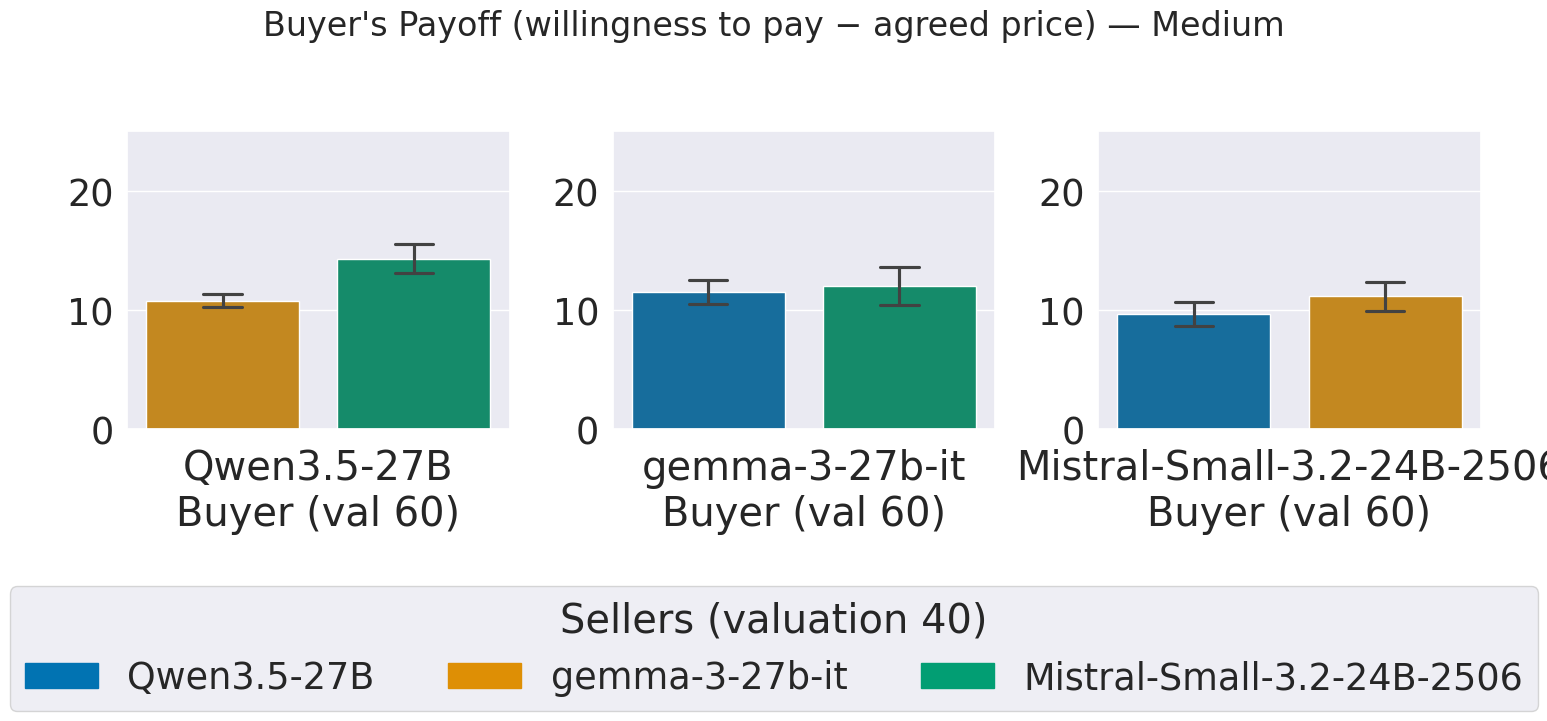

In [48]:
plot_buysell("medium")